In [1]:
# Further testing - this version with fixed sunkit-spex
# 
# 14-Jul-06 IGH

In [2]:
from astropy.time import Time, TimeDelta
from astropy import units as u
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Using sunkit-spex 0.1.dev214+g7f350be51
from sunkit_spex.legacy import thermal
from sunkit_spex.extern.rhessi import RhessiLoader
from sunkit_spex.legacy.fitting.fitter import Fitter
from sunkit_spex.legacy.fitting.albedo import get_albedo_matrix

# import warnings
# warnings.filterwarnings("ignore", category=RuntimeWarning) 
plt.rcParams['font.size'] = 14

/Users/iain/github/sunkit-spex/sunkit_spex/legacy/thermal.py:763: UserWarning: Some input energy values outside valid range of 1.0002920302956426--200.15819869050395 keV. Flux will be zero outside this range.
  warnings.warn(message)


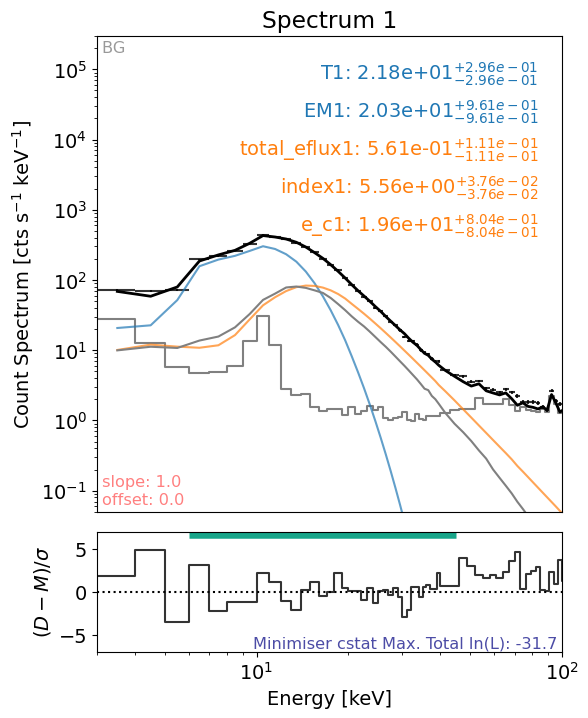

In [3]:
fdir = "fits/"
fspec="hsi_spectrum_20021005_0938_1114_3_250keV_alld.fits"
fsrm="hsi_srm_20021005_1040_1056_3_250keV_alld.fits"

ftims=Time(['2002-10-05T10:41:20.000','2002-10-05T10:42:24.000'],format='isot')
btims=Time(['2002-10-05T10:38:32.000','2002-10-05T10:40:32.000'],format='isot')

rhess_spec = RhessiLoader(spectrum_fn=fdir+fspec, srm_fn=fdir+fsrm)
rhess_spec.update_background_times(btims[0],btims[1])
rhess_spec.update_event_times(ftims[0],ftims[1])

fitter = Fitter(rhess_spec)
fitter.albedo_corr=True
# Flare at 382.7, -405.2 -> spex source angle 35.4919
fitter.albedo_angle=35.4919 * u.deg

fitter.model = "(f_vth+thick_fn)"
fitter.loglikelihood = "cstat"

# As A1 only fit > 6keV
fitter.energy_fitting_range = [6,15]
fitter.params["T1_spectrum1"] = {"Value":22, "Bounds":(10, 30)}
fitter.params["EM1_spectrum1"] = {"Value":10, "Bounds":(1e-1, 1e3)}
fitter.params["total_eflux1_spectrum1"] = {"Status":"fix", "Value":0.1, "Bounds":(1e-3, 1e2)}
fitter.params["index1_spectrum1"] = {"Status":"fix", "Value":6, "Bounds":(2, 12)}
fitter.params["e_c1_spectrum1"] = {"Status":"fix", "Value":20, "Bounds":(5, 30)}
spec_fit = fitter.fit()

# Then non-thermal fit higher energy
fitter.energy_fitting_range = [15,45]
fitter.params["T1_spectrum1"] = "fix"
fitter.params["EM1_spectrum1"] = "fix"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

# The do the full range
fitter.energy_fitting_range = [6,45]
fitter.params["T1_spectrum1"] = "free"
fitter.params["EM1_spectrum1"] = "free"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

xlims, ylims = [3,100], [5e-2,3e5]

plt.figure(figsize=(6,8))
axes, res_axes = fitter.plot()
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()

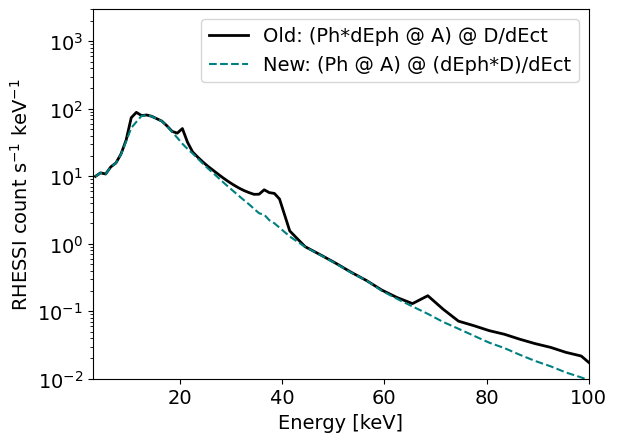

In [18]:
from sunkit_spex.legacy.fitting.fitter import make_model

# Reproduce fitter albedo count component using make_model()
photon_bin_widths = np.diff(Eph, axis=1).ravel()
count_bin_widths = np.asarray(rhess_spec._loaded_spec_data['count_channel_binning']).ravel()

# fitter._counts_model passes photon model multiplied by photon bin widths
photon_spec_binned = phi_total * photon_bin_widths

_, ac_old = make_model(
    energies=Eph,
    photon_model=photon_spec_binned,
    parameters=None,
    srm=D,
    albedo_corr=True,
    albedo_angle=fitter.albedo_angle,
    albedo_anisotropy=fitter.albedo_anisotropy,
 )

# New way where providing photon_bin_widths changes the internal calculation
_, ac_new = make_model(
    energies=Eph,
    photon_model=photon_spec_binned,
    parameters=None,
    photon_energy_widths=photon_bin_widths,
    srm=D,
    albedo_corr=True,
    albedo_angle=fitter.albedo_angle,
    albedo_anisotropy=fitter.albedo_anisotropy,
 )

# fitter._calculate_model then divides by count bin widths for plotting units
fal_ac_old = np.asarray(ac_old).ravel() / count_bin_widths
fal_ac_new = np.asarray(ac_new).ravel() / count_bin_widths

plt.plot(engs, fal_ac_old, label='Old: (Ph*dEph @ A) @ D/dEct', color='black', linewidth=2)
plt.plot(engs, fal, label='New: (Ph @ A) @ (dEph*D)/dEct', color='teal',linestyle='dashed')
# plt.plot(engs, fal2, label='fal2=(phi @ A) @ D', linestyle='dashed', color='magenta')
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
plt.xlim([3,100])
plt.ylim([1e-2,3e3])
plt.legend()
plt.show()